<a href="https://colab.research.google.com/github/Oladahmad/FInal_year_projects/blob/main/crop_yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("yield_df.csv")

df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
# check structure and data quality and cleanliness

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (28242, 8)

Data Types:
 Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing Values:
 Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Duplicate Rows: 0


In [7]:
# basic statistics for each columns
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


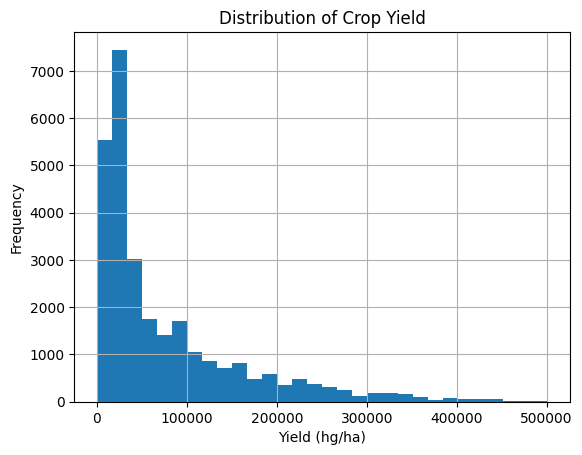

In [8]:
# distribution of crop yield
plt.figure()
df["hg/ha_yield"].hist(bins=30)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.show()

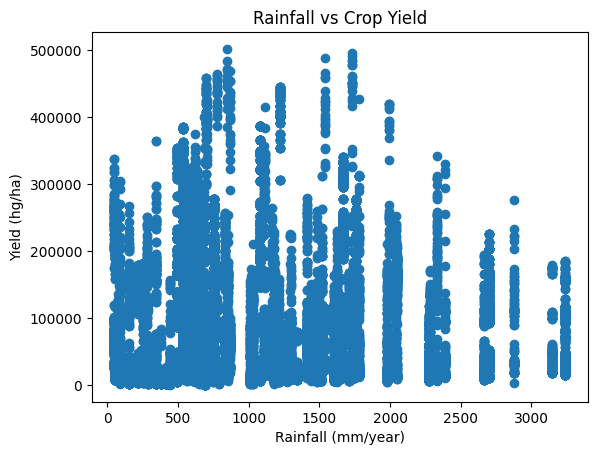

In [9]:
# relationship between rainfall and yield
plt.figure()
plt.scatter(df["average_rain_fall_mm_per_year"], df["hg/ha_yield"])
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm/year)")
plt.ylabel("Yield (hg/ha)")
plt.show()

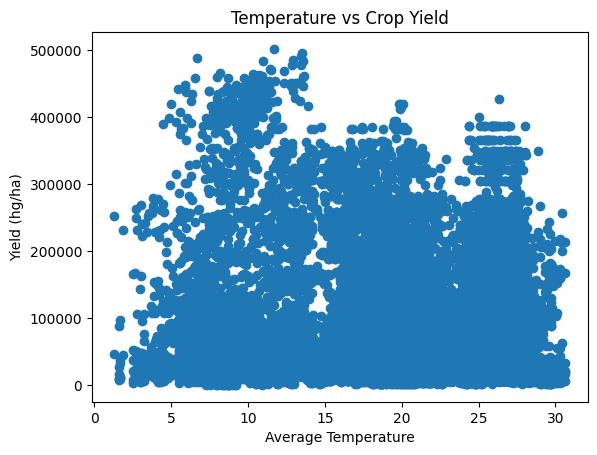

In [10]:
# relationship between temperature and yield
plt.figure()
plt.scatter(df["avg_temp"], df["hg/ha_yield"])
plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature")
plt.ylabel("Yield (hg/ha)")
plt.show()

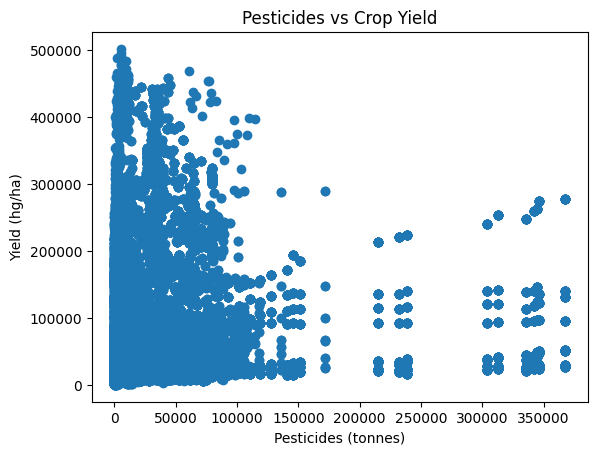

In [11]:
# relationship between pesticides and yield
plt.figure()
plt.scatter(df["pesticides_tonnes"], df["hg/ha_yield"])
plt.title("Pesticides vs Crop Yield")
plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Yield (hg/ha)")
plt.show()

In [12]:
# select relevant features
df = df[[
    "Area",
    "Item",
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp",
    "hg/ha_yield"
]]

df.head()

,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,Albania,Maize,1990,1485.0,121.0,16.37,36613
1,Albania,Potatoes,1990,1485.0,121.0,16.37,66667
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,23333
3,Albania,Sorghum,1990,1485.0,121.0,16.37,12500
4,Albania,Soybeans,1990,1485.0,121.0,16.37,7000


In [21]:
# encode categorical variables
df = pd.get_dummies(df, columns=["Area", "Item"])

df.head()

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield,Area_Albania,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,...,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,1485.0,121.0,16.37,36613,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,1990,1485.0,121.0,16.37,66667,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,1990,1485.0,121.0,16.37,23333,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,1990,1485.0,121.0,16.37,12500,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1990,1485.0,121.0,16.37,7000,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [22]:
# define features and target variable
X = df.drop("hg/ha_yield", axis=1)
y = df["hg/ha_yield"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (28242, 115)
Target shape: (28242,)


In [23]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (22593, 115)
Testing set: (5649, 115)


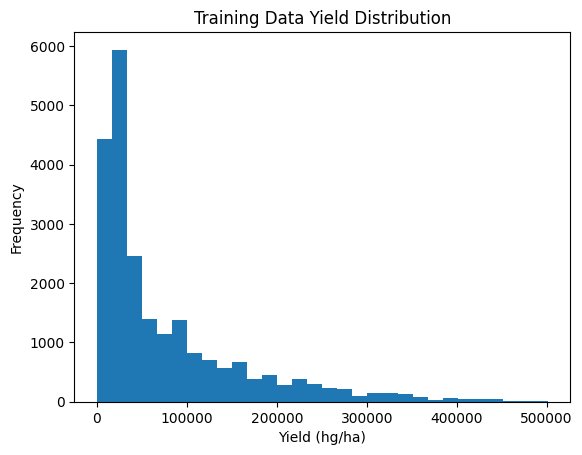

In [24]:
# check of target distribution after split
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_train, bins=30)
plt.title("Training Data Yield Distribution")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.show()

In [25]:
# import models and evaluation tools
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
# train models and make predictions
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor()
rf_model = RandomForestRegressor()

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [28]:
# evaluate models
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,29582.495023,42144.002983,0.755142
1,Decision Tree,3710.141264,12550.458339,0.978285
2,Random Forest,3490.785838,9523.262780,0.987497


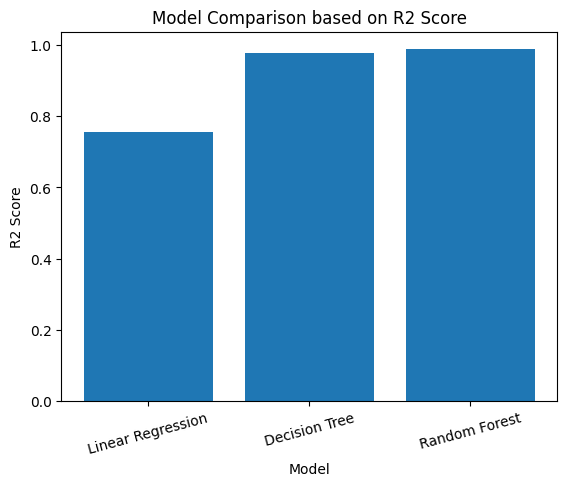

In [29]:
# visualize model comparison using R2 score
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show()

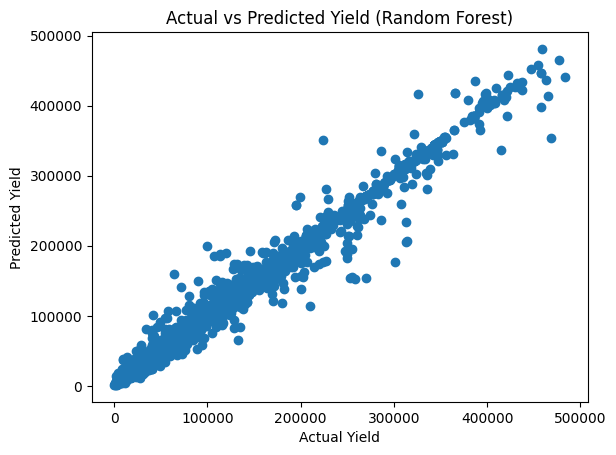

In [30]:
# compare predicted vs actual values for best model (random forest)
plt.figure()
plt.scatter(y_test, rf_pred)
plt.title("Actual vs Predicted Yield (Random Forest)")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.show()

In [31]:
# check feature importance using random forest
importances = rf_model.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
108,Item_Potatoes,0.369659
105,Item_Cassava,0.102292
112,Item_Sweet potatoes,0.086038
2,pesticides_tonnes,0.070275
46,Area_India,0.058354
3,avg_temp,0.044168
1,average_rain_fall_mm_per_year,0.043924
0,Year,0.032517
114,Item_Yams,0.027630
101,Area_United Kingdom,0.016752


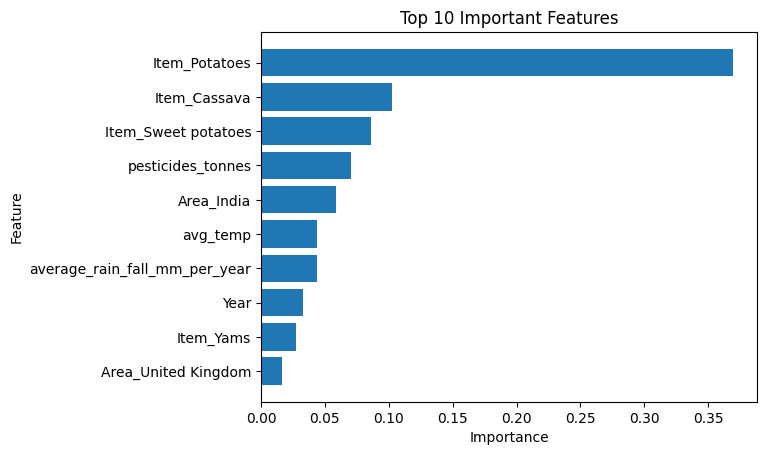

In [32]:
# plot top features
plt.figure()
top_features = feat_imp.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [33]:
# improved random forest model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [34]:
# evaluate improved model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

rf_mae, rf_rmse, rf_r2

(6282.843482822312, np.float64(12552.620614075273), 0.9782774455594645)

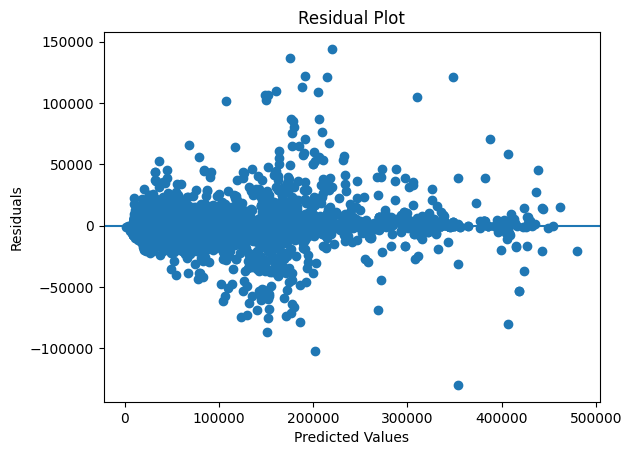

In [35]:
# residual plot
residuals = y_test - rf_pred

plt.figure()
plt.scatter(rf_pred, residuals)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(0)
plt.show()

In [36]:
# save model
import pickle

with open("crop_yield_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)